Paper Referred : [LSTM-SNP: A long short-term memory model inspired from spiking neural P systems](https://drive.google.com/file/d/1V_n4Cn342ShMSTQDLnfiGsBgXEeTGyJE/view?usp=sharing)




In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Model
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import tensorflow as tf
import time as _timer_module
import torch

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

NOISE_LEVELS = [0.0, 0.005, 0.05, 0.10]

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

NOISE_LEVELS = [0.0, 0.005, 0.05, 0.10]

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================


Architecture of Neuron :

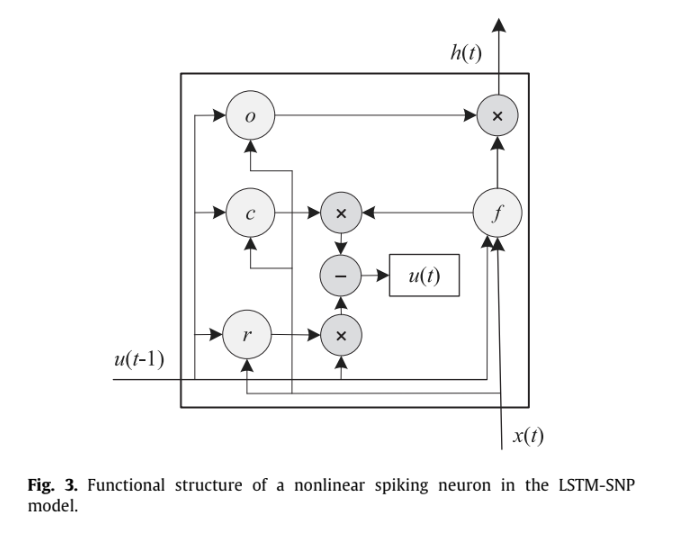


In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

try:
    tf.config.set_visible_devices([], 'GPU')
    print('Forcing CPU execution (disabled GPU visibility).')
except RuntimeError as e:
    print(e)


In [1]:
# ============================================================
# ALL IMPORTS (consolidated)
# ============================================================


## Reset Gate

$$
r(t) = \rho\left( W_r x(t) + U_r u(t-1) + b_r \right)
$$

## Consumption Gate

$$
c(t) = \rho\left( W_c x(t) + U_c u(t-1) + b_c \right)
$$

## Output Gate

$$
o(t) = \rho\left( W_o x(t) + U_o u(t-1) + b_o \right)
$$

## Generated Spikes

$$
a(t) = f\left( W_a x(t) + U_a u(t-1) + b_a \right)
$$

---

### Parameter Dimensions

$$
W_* \in \mathbb{R}^{d \times h}, \qquad
U_* \in \mathbb{R}^{h \times h}, \qquad
b_* \in \mathbb{R}^{h}
$$

---

### Activations

$$
\rho(\cdot) = \text{hard sigmoid}, \qquad
f(\cdot) = \tanh
$$

In [3]:

@tf.keras.utils.register_keras_serializable()
class LSTMSNPCell(layers.Layer):
    """
      This serves as an RNN Cell Instance.
    """
    def __init__(self, units,
                 activation='tanh',
                 recurrent_activation='hard_sigmoid',
                 **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units      # REQUIRED
        self.output_size = units     # REQUIRED

        self.activation = tf.keras.activations.get(activation)
        self.recurrent_activation = tf.keras.activations.get(recurrent_activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )

        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )

        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        r = self.recurrent_activation(z0) #reset :how much previous state reset
        c = self.recurrent_activation(z1) #how much of previous state (u) is consumed.Wrt to current i/p, refer to the T/g(t)->f(t) philosophy
        o = self.recurrent_activation(z2) # generation : how much spike generated.
        a = self.recurrent_activation(z3)

        u = r * u_tm1 - c * a #internal state of LSTM-SNP
        h = o * a #output of SNP

        return h, [u]

Wrapping in RNN (As directeed in paper)

In [4]:
def build_model(input_dim, units, batch_size):
    cell = LSTMSNPCell(units)
    rnn = layers.RNN(cell, return_sequences=False, stateful=True)

    inputs = tf.keras.Input(
        batch_shape=(batch_size, 1, input_dim)
    )
    x = rnn(inputs)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [5]:
model = build_model(input_dim=1, units=8, batch_size=1)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 1, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (1, 8)                 │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

**TESTING ON DOW_JONES DATASET (from GITHUB REPO attached to paper)**

# LSTM-SNP Experiment Pipeline — Dow Jones Dataset

## 1. Load Time Series Data
- Read monthly Dow Jones closing prices
- Parse date column
- Extract raw numeric values


## 2. First-Order Differencing
- Remove trend component
- Compute:

  diff(t) = raw(t) − raw(t−1)

- Purpose: make series more stationary


## 3. Convert to Supervised Learning Format
- Use lag = 1
- Create input-output pairs:

  X(t) = diff(t−1)  
  y(t) = diff(t)

- Fill initial NaN with 0


## 4. Train-Test Split
- Last 60 samples → Test set
- Remaining samples → Training set



## 5. Feature Scaling
- Apply MinMaxScaler
- Scale to range [-1, 1]
- Fit scaler on training set only
- Transform both train and test


## 6. Reshape for RNN Input
- Reshape X_train to:

  (samples, timesteps=1, features=1)

- Required input shape for RNN


## 7. Model Construction
- Custom LSTM-SNP cell (8 units)
- Wrapped inside RNN layer
- Dense(1) output layer
- Loss: Mean Squared Error
- Optimizer: Adam



## 8. Model Training
- Epochs: 200
- Batch size: 1
- shuffle=False (preserve sequence order)
- Backpropagation Through Time



## 9. Rolling Prediction (One-Step Ahead)
For each test sample:
- Predict next differenced value
- Inverse scale
- Inverse differencing:

  predicted_raw(t) = predicted_diff(t) + raw(t−1)



## 10. Evaluation Metrics
- RMSE
- MSE
- NMSE:

  NMSE = MSE / ||prediction − mean(actual)||²


## 11. Visualization
- Plot actual vs predicted
- Observe tracking behavior

In [6]:

def parser(x):
    return pd.to_datetime(x)

series = pd.read_csv(
    'content/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")


Data shape: (251,)
First 5 values: [2038.199951 2013.780029 2011.709961 1985.319946 1945.969971]


In [7]:
def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [8]:
def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)

In [9]:
train, test = supervised[:-60], supervised[-60:]

In [10]:
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

In [11]:
X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]

In [12]:
# ============================================================
# 30-Run Experiment Protocol (matching reference test.py)
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')

    # Fix #4: Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)

    # Build stateful model (Fix #2)
    tf.keras.backend.clear_session()
    model = build_model(input_dim=1, units=8, batch_size=1)

    # Fix #3: Unit forget bias — set consume gate (c) bias to 1.0
    # Access the RNN layer's cell weights
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()  # [kernel, recurrent_kernel, bias]
    bias = weights[2].copy()
    bias[8:16] = 1.0  # units=8, so bias[units:2*units] = bias[8:16]
    weights[2] = bias
    cell.set_weights(weights)

    # Fix #2: Stateful training with manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train,
            y_train,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Fix #6: Warm-up prediction pass on training data
    # This conditions the hidden states before test predictions
    train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
    model.predict(train_reshaped, batch_size=1, verbose=0)

    # Test predictions (single-step)
    predictions = []
    for i in range(len(test_scaled)):
        X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
        X_input = X.reshape(1, 1, len(X))
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling
        new_row = [x for x in X] + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train) + i]

        predictions.append(inverted)

        expected = raw_values[len(train) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


===== RUN 1/30 =====

Training complete for run 1
Month=1, Predicted=2155.9708, Expected=2158.2200
Month=2, Predicted=2158.7102, Expected=2164.1899
Month=3, Predicted=2164.5590, Expected=2160.3899
Month=4, Predicted=2161.0485, Expected=2161.3501
Month=5, Predicted=2161.8772, Expected=2137.6699
Month=6, Predicted=2139.0270, Expected=2130.2600
Month=7, Predicted=2131.1865, Expected=2139.6799
Month=8, Predicted=2140.0494, Expected=2132.9500
Month=9, Predicted=2133.7632, Expected=2138.3101
Month=10, Predicted=2138.7444, Expected=2140.8101
Month=11, Predicted=2141.2927, Expected=2142.5100
Month=12, Predicted=2143.0027, Expected=2139.4299
Month=13, Predicted=2140.0741, Expected=2148.5000
Month=14, Predicted=2148.7656, Expected=2149.7200
Month=15, Predicted=2150.1963, Expected=2136.9700
Month=16, Predicted=2137.9204, Expected=2144.0601
Month=17, Predicted=2144.4265, Expected=2132.2300
Month=18, Predicted=2133.1760, Expected=2129.7800
Month=19, Predicted=2130.4729, Expected=2128.6799
Month=20

In [13]:
# ============================================================
# Summary Statistics (matching reference calculate.py)
# ============================================================

print('\n===== FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.10f} ± {np.var(all_rmse):.15f}')
print(f'MSE:  {np.mean(all_mse):.10f} ± {np.var(all_mse):.15f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.var(all_nmse):.15f}')

# Best run (minimum RMSE)
best_idx = all_rmse.index(min(all_rmse))
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.15f}')
print(f'  MSE:  {all_mse[best_idx]:.15f}')
print(f'  NMSE: {all_nmse[best_idx]:.15f}')

print(f'\nAll RMSE values: {all_rmse}')


===== FINAL RESULTS (30 runs) =====
RMSE: 11.1421630063 ± 0.000621883114825
MSE:  124.1484183423 ± 0.309828852128366
NMSE: 0.0007537286 ± 0.000000000019196

Best run: 7
  RMSE: 11.104517165466868
  MSE:  123.310301478148332
  NMSE: 0.000747710662933

All RMSE values: [11.138179027650908, 11.174939675730474, 11.145942758729628, 11.117131467304247, 11.231851919171639, 11.143783199639836, 11.104517165466868, 11.148247081744982, 11.167829208695368, 11.132322255597188, 11.120231375204781, 11.149019876749414, 11.147855267304285, 11.11448399655324, 11.156366906379706, 11.131986679357421, 11.127967471224531, 11.136432477861225, 11.13416416255033, 11.136019983782306, 11.123445200990293, 11.131660369789728, 11.168992245806395, 11.16223105550069, 11.119589205124981, 11.117272027996492, 11.164132709896712, 11.132256636281927, 11.116501704892501, 11.169537076351519]


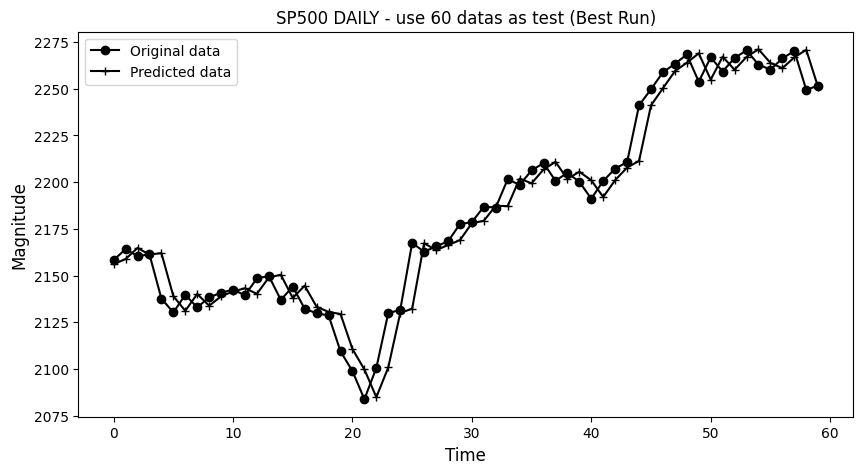

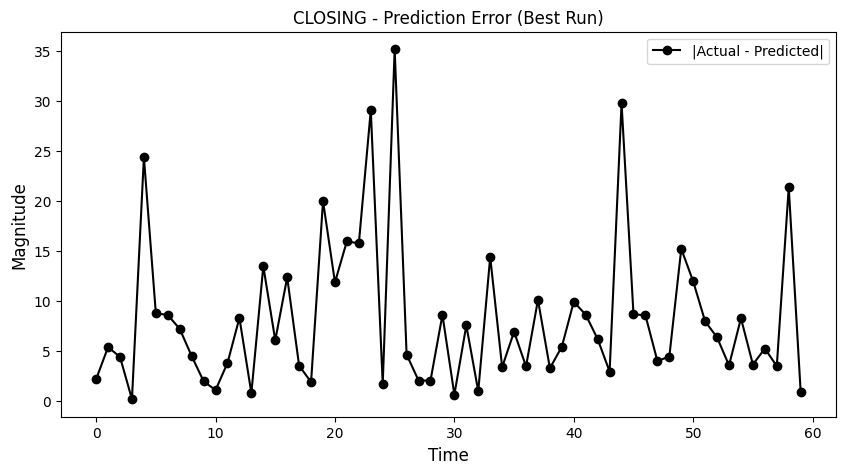

In [14]:
# Plot best run predictions vs actual
actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_predictions, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('SP500 DAILY - use 60 datas as test (Best Run)')
plt.show()

# Error plot
error = abs(np.array(actual) - np.array(best_predictions))
plt.figure(figsize=(10, 5))
plt.plot(error, 'k-o', label='|Actual - Predicted|')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('CLOSING - Prediction Error (Best Run)')
plt.show()

In [15]:
# Final metrics summary from best run
print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]}')
print(f'MSE:  {all_mse[best_idx]}')
print(f'NMSE: {all_nmse[best_idx]}')

=== Best Run Metrics ===
RMSE: 11.104517165466868
MSE:  123.31030147814833
NMSE: 0.0007477106629329008


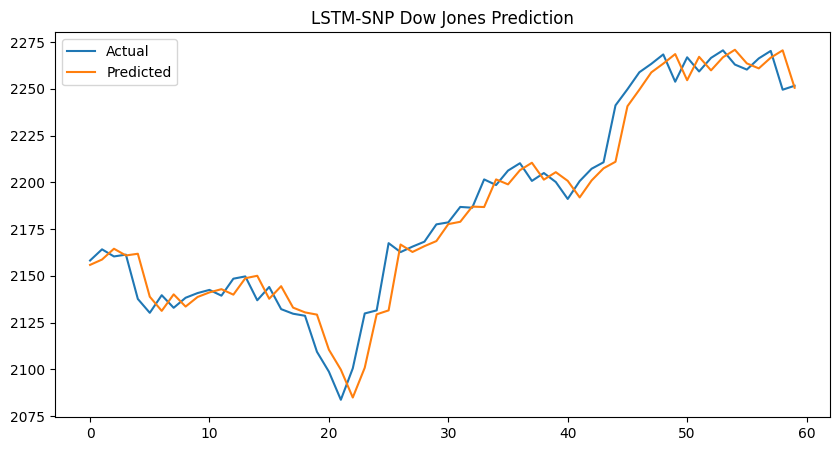

In [16]:
plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("LSTM-SNP Dow Jones Prediction")
plt.show()

Report

# **Bi-LSTM SNP**

In [17]:
def build_bilstm_snp_model(input_dim, units, batch_size):
    """
    Stateful BiLSTM-SNP model.
    Both forward and backward cells are independent LSTMSNPCell clones.
    Bidirectional merge_mode='concat' → output dim = 2*units.
    """
    cell_fw = LSTMSNPCell(units)
    cell_bw = LSTMSNPCell(units)

    rnn_fw = layers.RNN(cell_fw, return_sequences=False, stateful=True)
    rnn_bw = layers.RNN(cell_bw, return_sequences=False, stateful=True, go_backwards=True)

    bi_rnn = layers.Bidirectional(rnn_fw, backward_layer=rnn_bw)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x = bi_rnn(inputs)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [18]:
bi_model_check = build_bilstm_snp_model(input_dim=1, units=8, batch_size=1)
bi_model_check.summary()
print(f"\nTotal params: {bi_model_check.count_params()}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, 1, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (1, 16)                │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657 (2.57 KB)

 Trainable params: 657 (2.57 KB)

 Non-trainable params: 0 (0.00 B)


Total params: 657


In [19]:
# ============================================================
# BiLSTM-SNP: 30-Run Experiment Protocol
# (Protocol-aligned with baseline LSTM-SNP)
# ============================================================

bi_all_rmse = []
bi_all_mse = []
bi_all_nmse = []
bi_all_predictions = []

for run in range(30):
    print(f'\n===== BiLSTM-SNP RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful BiLSTM model
    model = build_bilstm_snp_model(input_dim=1, units=8, batch_size=1)

    # Unit forget bias for BOTH forward and backward cells
    bi_layer = model.layers[1]  # Bidirectional layer
    for rnn_sub in [bi_layer.forward_layer, bi_layer.backward_layer]:
        cell = rnn_sub.cell
        weights = cell.get_weights()  # [kernel, recurrent_kernel, bias]
        bias = weights[2].copy()
        bias[8:16] = 1.0  # units=8, bias[units:2*units] = consume gate
        weights[2] = bias
        cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train,
            y_train,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        bi_layer.forward_layer.reset_states()
        bi_layer.backward_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass on training data
    train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
    model.predict(train_reshaped, batch_size=1, verbose=0)

    # Test predictions (single-step)
    predictions = []
    for i in range(len(test_scaled)):
        X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
        X_input = X.reshape(1, 1, len(X))
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling
        new_row = [x for x in X] + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train) + i]

        predictions.append(inverted)

        expected = raw_values[len(train) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics (matching calculate.py)
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    bi_all_rmse.append(rmse)
    bi_all_mse.append(mse)
    bi_all_nmse.append(nmse)
    bi_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


===== BiLSTM-SNP RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2155.4200, Expected=2158.2200
Month=2, Predicted=2158.1011, Expected=2164.1899
Month=3, Predicted=2163.9593, Expected=2160.3899
Month=4, Predicted=2160.4945, Expected=2161.3501
Month=5, Predicted=2161.2990, Expected=2137.6699
Month=6, Predicted=2138.5029, Expected=2130.2600
Month=7, Predicted=2130.5220, Expected=2139.6799
Month=8, Predicted=2139.3375, Expected=2132.9500
Month=9, Predicted=2133.1447, Expected=2138.3101
Month=10, Predicted=2138.1001, Expected=2140.8101
Month=11, Predicted=2140.6912, Expected=2142.5100
Month=12, Predicted=2142.4239, Expected=2139.4299
Month=13, Predicted=2139.5142, Expected=2148.5000
Month=14, Predicted=2148.1719, Expected=2149.7200
Month=15, Predicted=2149.6503, Expected=2136.9700
Month=16, Predicted=2137.4028, Expected=2144.0601
Month=17, Predicted=2143.8109, Expected=2132.2300
Month=18, Predicted=2132.6221, Expected=2129.7800
Month=19, Predicted=2129.8531, Expected=2128.679


===== BiLSTM-SNP FINAL RESULTS (30 runs) =====
RMSE: 11.1995005549 ± 0.000626517660041
MSE:  125.4294391979 ± 0.314448264486112
NMSE: 0.0007616362 ± 0.000000000014834

Best run: 3
  RMSE: 11.147305738020002
  MSE:  124.262425216893661
  NMSE: 0.000753080406526


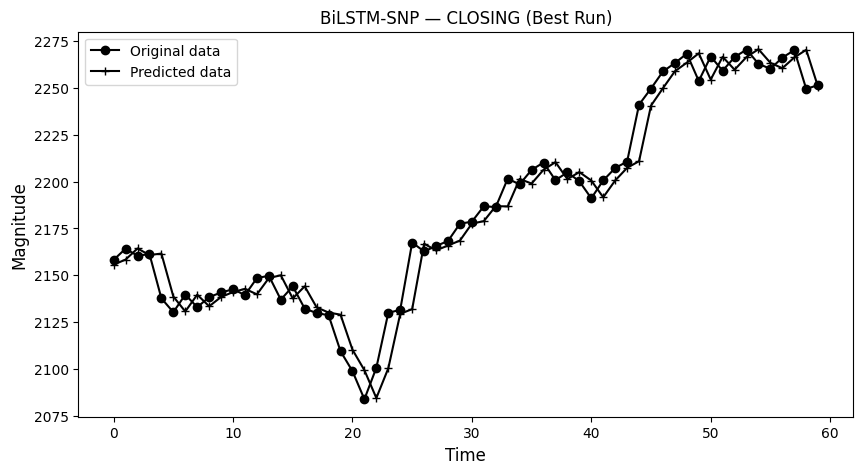

In [20]:
# ============================================================
# BiLSTM-SNP Summary Statistics
# ============================================================

print('\n===== BiLSTM-SNP FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(bi_all_rmse):.10f} ± {np.var(bi_all_rmse):.15f}')
print(f'MSE:  {np.mean(bi_all_mse):.10f} ± {np.var(bi_all_mse):.15f}')
print(f'NMSE: {np.mean(bi_all_nmse):.10f} ± {np.var(bi_all_nmse):.15f}')

best_bi_idx = bi_all_rmse.index(min(bi_all_rmse))
print(f'\nBest run: {best_bi_idx+1}')
print(f'  RMSE: {bi_all_rmse[best_bi_idx]:.15f}')
print(f'  MSE:  {bi_all_mse[best_bi_idx]:.15f}')
print(f'  NMSE: {bi_all_nmse[best_bi_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_bi_preds = bi_all_predictions[best_bi_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_bi_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('BiLSTM-SNP — CLOSING (Best Run)')
plt.show()

# **Incorporating attention mechanism**

# Attention Mechanism in LSTM-SNP

## 1. Sequence Representation

Standard LSTM-SNP compresses a sequence as:

$$
x_1, x_2, \dots, x_T \longrightarrow h_T
$$

This creates an information bottleneck.

Instead, with attention we retain all hidden states:

$$
H = \{h_1, h_2, \dots, h_T\}
$$

where:

$$
h_t \in \mathbb{R}^{d}
$$



## 2. Alignment Score Function (Additive Attention)

Each hidden state receives a score:

$$
e_t = v^\top \tanh(W h_t + b)
$$

where:

$$
W \in \mathbb{R}^{d \times d},
\quad
v \in \mathbb{R}^{d},
\quad
b \in \mathbb{R}^{d}
$$



## 3. Softmax Normalization

Attention weights are computed as:

$$
\alpha_t =
\frac{\exp(e_t)}
{\sum_{k=1}^{T} \exp(e_k)}
$$

with:

$$
\sum_{t=1}^{T} \alpha_t = 1
$$


## 4. Context Vector

The context vector is a weighted sum of hidden states:

$$
c = \sum_{t=1}^{T} \alpha_t h_t
$$

where:

$$
c \in \mathbb{R}^{d}
$$



## 5. Final Prediction

The final output is computed as:

$$
\hat{y} = W_o c + b_o
$$

where:

$$
W_o \in \mathbb{R}^{1 \times d},
\quad
b_o \in \mathbb{R}
$$


## 6. Full Compact Form

$$
e_t = v^\top \tanh(W h_t + b)
$$

$$
\alpha_t =
\frac{\exp(e_t)}
{\sum_{k=1}^{T} \exp(e_k)}
$$

$$
c = \sum_{t=1}^{T} \alpha_t h_t
$$

$$
\hat{y} = W_o c + b_o
$$

In [21]:
class SimpleAttention(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, hidden_states):
        # hidden_states: (batch, T, units)

        score = self.V(tf.nn.tanh(self.W(hidden_states)))
        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * hidden_states
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [22]:
def build_lstm_snp_attention(input_dim, units, batch_size):
    """
    Stateful LSTM-SNP + Attention model.
    return_sequences=True to provide all hidden states to attention.
    """
    cell = LSTMSNPCell(units)
    rnn_layer = layers.RNN(cell, return_sequences=True, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, None, input_dim))
    sequence_output = rnn_layer(inputs)

    attention_layer = SimpleAttention(units)
    context = attention_layer(sequence_output)

    outputs = layers.Dense(1)(context)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [23]:
# ============================================================
# LSTM-SNP + Attention (lag=1) — DEGENERATE ATTENTION CONTROL
# With T=1 timestep: softmax([e_1]) = [1.0], α_1 = 1 always.
# Context vector = h_1. Attention has zero selective effect.
# This serves as a control experiment.
# ============================================================
att_model_check = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)
att_model_check.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (1, None, 8)           │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention                │ (1, 8)                 │            81 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410 (1.60 KB)

 Trainable params: 410 (1.60 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ============================================================
# LSTM-SNP + Attention (lag=1): 30-Run Protocol
# DEGENERATE ATTENTION CONTROL (T=1, α₁=1 always)
# ============================================================

att1_all_rmse = []
att1_all_mse = []
att1_all_nmse = []
att1_all_predictions = []

for run in range(30):
    print(f'\n===== Attention(lag=1) RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful attention model
    model = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)

    # Unit forget bias initialization
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()
    bias = weights[2].copy()
    bias[8:16] = 1.0
    weights[2] = bias
    cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train,
            y_train,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass
    train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
    model.predict(train_reshaped, batch_size=1, verbose=0)

    # Test predictions (single-step)
    predictions = []
    for i in range(len(test_scaled)):
        X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
        X_input = X.reshape(1, 1, len(X))
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling
        new_row = [x for x in X] + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train) + i]

        predictions.append(inverted)

        expected = raw_values[len(train) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    att1_all_rmse.append(rmse)
    att1_all_mse.append(mse)
    att1_all_nmse.append(nmse)
    att1_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


===== Attention(lag=1) RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2155.9843, Expected=2158.2200
Month=2, Predicted=2158.7680, Expected=2164.1899
Month=3, Predicted=2164.6286, Expected=2160.3899
Month=4, Predicted=2161.0819, Expected=2161.3501
Month=5, Predicted=2161.9326, Expected=2137.6699
Month=6, Predicted=2138.9400, Expected=2130.2600
Month=7, Predicted=2131.1668, Expected=2139.6799
Month=8, Predicted=2140.0889, Expected=2132.9500
Month=9, Predicted=2133.7460, Expected=2138.3101
Month=10, Predicted=2138.7876, Expected=2140.8101
Month=11, Predicted=2141.3363, Expected=2142.5100
Month=12, Predicted=2143.0534, Expected=2139.4299
Month=13, Predicted=2140.1099, Expected=2148.5000
Month=14, Predicted=2148.8519, Expected=2149.7200
Month=15, Predicted=2150.2589, Expected=2136.9700
Month=16, Predicted=2137.9154, Expected=2144.0601
Month=17, Predicted=2144.5022, Expected=2132.2300
Month=18, Predicted=2133.1629, Expected=2129.7800
Month=19, Predicted=2130.4974, Expected=21


===== LSTM-SNP + Attention (lag=1) — DEGENERATE ATTENTION CONTROL =====
Note: T=1, softmax([e_1]) = [1.0], α_1 = 1 always. Attention has NO selective effect.

RMSE: 11.1364333586 ± 0.000560849565864
MSE:  124.0207088000 ± 0.278694917189056
NMSE: 0.0007527141 ± 0.000000000018707

Best run: 15
  RMSE: 11.082946180478274
  MSE:  122.831696039377945
  NMSE: 0.000742946065052


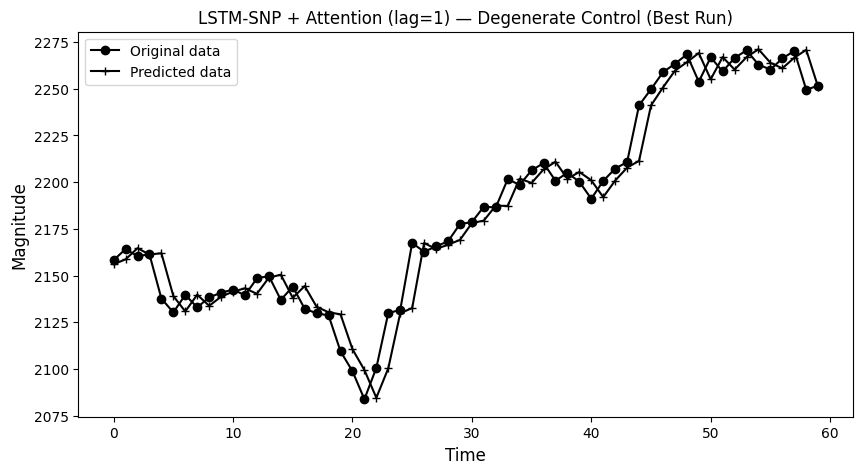

In [25]:
# ============================================================
# Attention (lag=1) Summary — Degenerate Attention Control
# ============================================================

print('\n===== LSTM-SNP + Attention (lag=1) — DEGENERATE ATTENTION CONTROL =====')
print('Note: T=1, softmax([e_1]) = [1.0], α_1 = 1 always. Attention has NO selective effect.')
print(f'\nRMSE: {np.mean(att1_all_rmse):.10f} ± {np.var(att1_all_rmse):.15f}')
print(f'MSE:  {np.mean(att1_all_mse):.10f} ± {np.var(att1_all_mse):.15f}')
print(f'NMSE: {np.mean(att1_all_nmse):.10f} ± {np.var(att1_all_nmse):.15f}')

best_att1_idx = att1_all_rmse.index(min(att1_all_rmse))
print(f'\nBest run: {best_att1_idx+1}')
print(f'  RMSE: {att1_all_rmse[best_att1_idx]:.15f}')
print(f'  MSE:  {att1_all_mse[best_att1_idx]:.15f}')
print(f'  NMSE: {att1_all_nmse[best_att1_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_att1_preds = att1_all_predictions[best_att1_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_att1_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('LSTM-SNP + Attention (lag=1) — Degenerate Control (Best Run)')
plt.show()

# LSTM-SNP + Attention (lag=5)

In [26]:
# Redefine supervised data with lag=5

lag = 5
supervised_lag5 = timeseries_to_supervised(diff_values, lag)

In [27]:
# lag=5 data preparation (distinct variable names to avoid shadowing)
train5, test5 = supervised_lag5[:-60], supervised_lag5[-60:]

scaler5 = MinMaxScaler(feature_range=(-1, 1))
scaler5.fit(train5)

train5_scaled = scaler5.transform(train5)
test5_scaled = scaler5.transform(test5)

X_train5 = train5_scaled[:, :-1].reshape((-1, lag, 1))
y_train5 = train5_scaled[:, -1]

X_test5 = test5_scaled[:, :-1].reshape((-1, lag, 1))
y_test5 = test5_scaled[:, -1]

print(f"X_train5 shape: {X_train5.shape}")  # (samples, 5, 1)
print(f"X_test5 shape:  {X_test5.shape}")   # (60, 5, 1)

X_train5 shape: (190, 5, 1)
X_test5 shape:  (60, 5, 1)


In [28]:
att5_model_check = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)
att5_model_check.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (1, None, 8)           │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_1              │ (1, 8)                 │            81 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410 (1.60 KB)

 Trainable params: 410 (1.60 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ============================================================
# LSTM-SNP + Attention (lag=5): 30-Run Protocol
# ============================================================

att5_all_rmse = []
att5_all_mse = []
att5_all_nmse = []
att5_all_predictions = []

for run in range(30):
    print(f'\n===== Attention(lag=5) RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful attention model (input_dim=1, lag=5 timesteps)
    model = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)

    # Unit forget bias initialization
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()
    bias = weights[2].copy()
    bias[8:16] = 1.0
    weights[2] = bias
    cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train5,
            y_train5,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass on training data
    model.predict(X_train5, batch_size=1, verbose=0)

    # Test predictions (single-step over lag=5 windows)
    predictions = []
    for i in range(len(test5_scaled)):
        X_input = X_test5[i].reshape(1, lag, 1)
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling: reconstruct full row [x1..x5, yhat]
        new_row = list(X_test5[i].flatten()) + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler5.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train5) + i]

        predictions.append(inverted)

        expected = raw_values[len(train5) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    att5_all_rmse.append(rmse)
    att5_all_mse.append(mse)
    att5_all_nmse.append(nmse)
    att5_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


===== Attention(lag=5) RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2155.6142, Expected=2158.2200
Month=2, Predicted=2158.7062, Expected=2164.1899
Month=3, Predicted=2164.2300, Expected=2160.3899
Month=4, Predicted=2160.6108, Expected=2161.3501
Month=5, Predicted=2161.5403, Expected=2137.6699
Month=6, Predicted=2138.6762, Expected=2130.2600
Month=7, Predicted=2131.3518, Expected=2139.6799
Month=8, Predicted=2140.7814, Expected=2132.9500
Month=9, Predicted=2134.0755, Expected=2138.3101
Month=10, Predicted=2139.4461, Expected=2140.8101
Month=11, Predicted=2140.9824, Expected=2142.5100
Month=12, Predicted=2142.4481, Expected=2139.4299
Month=13, Predicted=2139.5608, Expected=2148.5000
Month=14, Predicted=2148.3125, Expected=2149.7200
Month=15, Predicted=2149.6088, Expected=2136.9700
Month=16, Predicted=2137.3235, Expected=2144.0601
Month=17, Predicted=2144.3783, Expected=2132.2300
Month=18, Predicted=2132.7791, Expected=2129.7800
Month=19, Predicted=2130.4160, Expected=21


===== LSTM-SNP + Attention (lag=5) FINAL RESULTS (30 runs) =====
RMSE: 11.1462557983 ± 0.029520937885846
MSE:  124.2685392589 ± 15.695136393969978
NMSE: 0.0007576448 ± 0.000000000469193

Best run: 30
  RMSE: 10.892429876185787
  MSE:  118.645028607624710
  NMSE: 0.000725519846589


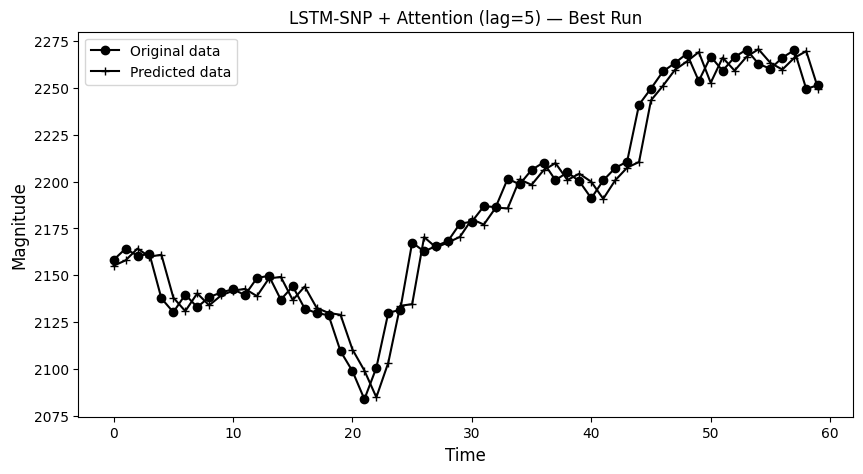

In [30]:
# ============================================================
# Attention (lag=5) Summary Statistics
# ============================================================

print('\n===== LSTM-SNP + Attention (lag=5) FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(att5_all_rmse):.10f} ± {np.var(att5_all_rmse):.15f}')
print(f'MSE:  {np.mean(att5_all_mse):.10f} ± {np.var(att5_all_mse):.15f}')
print(f'NMSE: {np.mean(att5_all_nmse):.10f} ± {np.var(att5_all_nmse):.15f}')

best_att5_idx = att5_all_rmse.index(min(att5_all_rmse))
print(f'\nBest run: {best_att5_idx+1}')
print(f'  RMSE: {att5_all_rmse[best_att5_idx]:.15f}')
print(f'  MSE:  {att5_all_mse[best_att5_idx]:.15f}')
print(f'  NMSE: {att5_all_nmse[best_att5_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_att5_preds = att5_all_predictions[best_att5_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_att5_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('LSTM-SNP + Attention (lag=5) — Best Run')
plt.show()

# LSTM-SNP + Attention (lag=10)


In [31]:
# Redefine supervised data with lag=10

lag10 = 10
supervised_lag10 = timeseries_to_supervised(diff_values, lag10)

train10, test10 = supervised_lag10[:-60], supervised_lag10[-60:]

scaler10 = MinMaxScaler(feature_range=(-1, 1))
scaler10.fit(train10)

train10_scaled = scaler10.transform(train10)
test10_scaled = scaler10.transform(test10)

X_train10 = train10_scaled[:, :-1].reshape((-1, lag10, 1))
y_train10 = train10_scaled[:, -1]

X_test10 = test10_scaled[:, :-1].reshape((-1, lag10, 1))
y_test10 = test10_scaled[:, -1]

print(f"X_train10 shape: {X_train10.shape}")  # (samples, 10, 1)
print(f"X_test10 shape:  {X_test10.shape}")   # (60, 10, 1)


X_train10 shape: (190, 10, 1)
X_test10 shape:  (60, 10, 1)


In [32]:
att10_model_check = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)
att10_model_check.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (1, None, 8)           │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_1              │ (1, 8)                 │            81 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410 (1.60 KB)

 Trainable params: 410 (1.60 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ============================================================
# LSTM-SNP + Attention (lag=10): 30-Run Protocol
# ============================================================

att10_all_rmse = []
att10_all_mse = []
att10_all_nmse = []
att10_all_predictions = []

for run in range(30):
    print(f'\n===== Attention(lag=10) RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful attention model (input_dim=1, lag=10 timesteps)
    model = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)

    # Unit forget bias initialization
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()
    bias = weights[2].copy()
    bias[8:16] = 1.0
    weights[2] = bias
    cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train10,
            y_train10,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass on training data
    model.predict(X_train10, batch_size=1, verbose=0)

    # Test predictions (single-step over lag=10 windows)
    predictions = []
    for i in range(len(test10_scaled)):
        X_input = X_test10[i].reshape(1, lag10, 1)
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling: reconstruct full row [x1..x10, yhat]
        new_row = list(X_test10[i].flatten()) + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler10.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train10) + i]

        predictions.append(inverted)

        expected = raw_values[len(train10) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    att10_all_rmse.append(rmse)
    att10_all_mse.append(mse)
    att10_all_nmse.append(nmse)
    att10_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')



===== Attention(lag=10) RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2156.1209, Expected=2158.2200
Month=2, Predicted=2159.1909, Expected=2164.1899
Month=3, Predicted=2165.1609, Expected=2160.3899
Month=4, Predicted=2161.3608, Expected=2161.3501
Month=5, Predicted=2162.3211, Expected=2137.6699
Month=6, Predicted=2138.6409, Expected=2130.2600
Month=7, Predicted=2131.2310, Expected=2139.6799
Month=8, Predicted=2140.6509, Expected=2132.9500
Month=9, Predicted=2133.9209, Expected=2138.3101
Month=10, Predicted=2139.2810, Expected=2140.8101
Month=11, Predicted=2141.7810, Expected=2142.5100
Month=12, Predicted=2143.4810, Expected=2139.4299
Month=13, Predicted=2140.4009, Expected=2148.5000
Month=14, Predicted=2149.4710, Expected=2149.7200
Month=15, Predicted=2150.6909, Expected=2136.9700
Month=16, Predicted=2137.9409, Expected=2144.0601
Month=17, Predicted=2145.0310, Expected=2132.2300
Month=18, Predicted=2133.2009, Expected=2129.7800
Month=19, Predicted=2130.7510, Expected=2


===== LSTM-SNP + Attention (lag=10) FINAL RESULTS (30 runs) =====
RMSE: 11.1726952763 ± 0.010084265910771
MSE:  124.8392040033 ± 4.972561971859451
NMSE: 0.0007635582 ± 0.000000000472051

Best run: 28
  RMSE: 10.884318189860899
  MSE:  118.468382458136844
  NMSE: 0.000706543468275


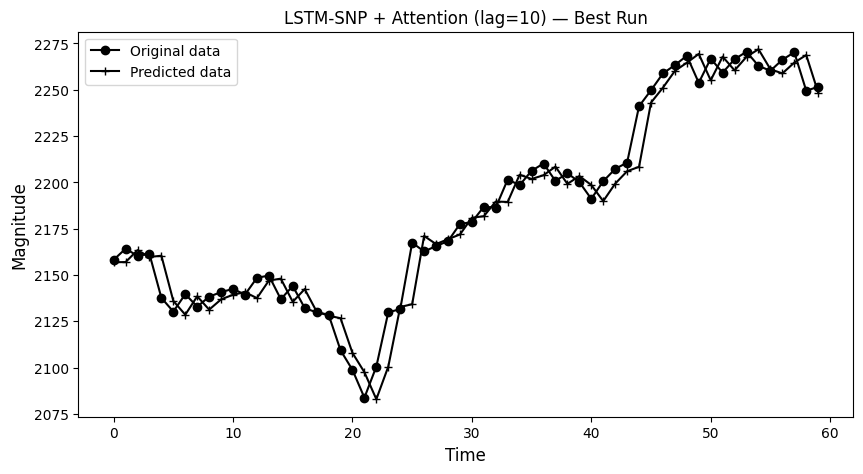

In [34]:
# ============================================================
# Attention (lag=10) Summary Statistics
# ============================================================

print('\n===== LSTM-SNP + Attention (lag=10) FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(att10_all_rmse):.10f} ± {np.var(att10_all_rmse):.15f}')
print(f'MSE:  {np.mean(att10_all_mse):.10f} ± {np.var(att10_all_mse):.15f}')
print(f'NMSE: {np.mean(att10_all_nmse):.10f} ± {np.var(att10_all_nmse):.15f}')

best_att10_idx = att10_all_rmse.index(min(att10_all_rmse))
print(f'\nBest run: {best_att10_idx+1}')
print(f'  RMSE: {att10_all_rmse[best_att10_idx]:.15f}')
print(f'  MSE:  {att10_all_mse[best_att10_idx]:.15f}')
print(f'  NMSE: {att10_all_nmse[best_att10_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_att10_preds = att10_all_predictions[best_att10_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_att10_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('LSTM-SNP + Attention (lag=10) — Best Run')
plt.show()


# LSTM-SNP + Attention (lag=20)


In [35]:
# Redefine supervised data with lag=20

lag20 = 20
supervised_lag20 = timeseries_to_supervised(diff_values, lag20)

train20, test20 = supervised_lag20[:-60], supervised_lag20[-60:]

scaler20 = MinMaxScaler(feature_range=(-1, 1))
scaler20.fit(train20)

train20_scaled = scaler20.transform(train20)
test20_scaled = scaler20.transform(test20)

X_train20 = train20_scaled[:, :-1].reshape((-1, lag20, 1))
y_train20 = train20_scaled[:, -1]

X_test20 = test20_scaled[:, :-1].reshape((-1, lag20, 1))
y_test20 = test20_scaled[:, -1]

print(f"X_train20 shape: {X_train20.shape}")  # (samples, 20, 1)
print(f"X_test20 shape:  {X_test20.shape}")   # (60, 20, 1)


X_train20 shape: (190, 20, 1)
X_test20 shape:  (60, 20, 1)


In [36]:
att20_model_check = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)
att20_model_check.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (1, None, 8)           │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_1              │ (1, 8)                 │            81 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410 (1.60 KB)

 Trainable params: 410 (1.60 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ============================================================
# LSTM-SNP + Attention (lag=20): 30-Run Protocol
# ============================================================

att20_all_rmse = []
att20_all_mse = []
att20_all_nmse = []
att20_all_predictions = []

for run in range(30):
    print(f'\n===== Attention(lag=20) RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful attention model (input_dim=1, lag=20 timesteps)
    model = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)

    # Unit forget bias initialization
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()
    bias = weights[2].copy()
    bias[8:16] = 1.0
    weights[2] = bias
    cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train20,
            y_train20,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass on training data
    model.predict(X_train20, batch_size=1, verbose=0)

    # Test predictions (single-step over lag=20 windows)
    predictions = []
    for i in range(len(test20_scaled)):
        X_input = X_test20[i].reshape(1, lag20, 1)
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling: reconstruct full row [x1..x20, yhat]
        new_row = list(X_test20[i].flatten()) + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler20.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train20) + i]

        predictions.append(inverted)

        expected = raw_values[len(train20) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    att20_all_rmse.append(rmse)
    att20_all_mse.append(mse)
    att20_all_nmse.append(nmse)
    att20_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')



===== Attention(lag=20) RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2157.8661, Expected=2158.2200
Month=2, Predicted=2160.9542, Expected=2164.1899
Month=3, Predicted=2166.8657, Expected=2160.3899
Month=4, Predicted=2162.9449, Expected=2161.3501
Month=5, Predicted=2161.6692, Expected=2137.6699
Month=6, Predicted=2137.7950, Expected=2130.2600
Month=7, Predicted=2130.3930, Expected=2139.6799
Month=8, Predicted=2139.5232, Expected=2132.9500
Month=9, Predicted=2132.7767, Expected=2138.3101
Month=10, Predicted=2138.1272, Expected=2140.8101
Month=11, Predicted=2140.5897, Expected=2142.5100
Month=12, Predicted=2140.3595, Expected=2139.4299
Month=13, Predicted=2137.2101, Expected=2148.5000
Month=14, Predicted=2146.6430, Expected=2149.7200
Month=15, Predicted=2147.5363, Expected=2136.9700
Month=16, Predicted=2134.4947, Expected=2144.0601
Month=17, Predicted=2141.4591, Expected=2132.2300
Month=18, Predicted=2129.9175, Expected=2129.7800
Month=19, Predicted=2127.2703, Expected=2


===== LSTM-SNP + Attention (lag=20) FINAL RESULTS (30 runs) =====
RMSE: 11.2621226640 ± 0.020527310516812
MSE:  126.8559342101 ± 10.218673920961193
NMSE: 0.0007784370 ± 0.000000000808524

Best run: 1
  RMSE: 10.916490080509755
  MSE:  119.169755677867883
  NMSE: 0.000714673520840


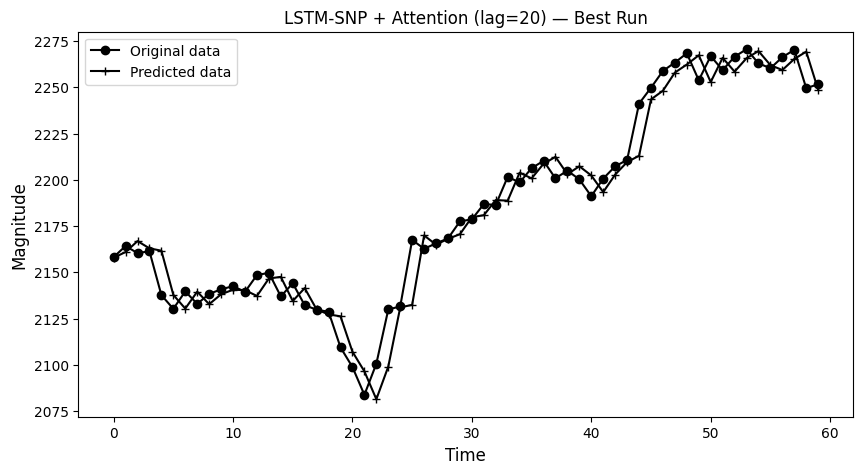

In [38]:
# ============================================================
# Attention (lag=20) Summary Statistics
# ============================================================

print('\n===== LSTM-SNP + Attention (lag=20) FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(att20_all_rmse):.10f} ± {np.var(att20_all_rmse):.15f}')
print(f'MSE:  {np.mean(att20_all_mse):.10f} ± {np.var(att20_all_mse):.15f}')
print(f'NMSE: {np.mean(att20_all_nmse):.10f} ± {np.var(att20_all_nmse):.15f}')

best_att20_idx = att20_all_rmse.index(min(att20_all_rmse))
print(f'\nBest run: {best_att20_idx+1}')
print(f'  RMSE: {att20_all_rmse[best_att20_idx]:.15f}')
print(f'  MSE:  {att20_all_mse[best_att20_idx]:.15f}')
print(f'  NMSE: {att20_all_nmse[best_att20_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_att20_preds = att20_all_predictions[best_att20_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_att20_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('LSTM-SNP + Attention (lag=20) — Best Run')
plt.show()


# LSTM-SNP + Attention (lag=30)


In [39]:
# Redefine supervised data with lag=30

lag30 = 30
supervised_lag30 = timeseries_to_supervised(diff_values, lag30)

train30, test30 = supervised_lag30[:-60], supervised_lag30[-60:]

scaler30 = MinMaxScaler(feature_range=(-1, 1))
scaler30.fit(train30)

train30_scaled = scaler30.transform(train30)
test30_scaled = scaler30.transform(test30)

X_train30 = train30_scaled[:, :-1].reshape((-1, lag30, 1))
y_train30 = train30_scaled[:, -1]

X_test30 = test30_scaled[:, :-1].reshape((-1, lag30, 1))
y_test30 = test30_scaled[:, -1]

print(f"X_train30 shape: {X_train30.shape}")  # (samples, 30, 1)
print(f"X_test30 shape:  {X_test30.shape}")   # (60, 30, 1)


X_train30 shape: (190, 30, 1)
X_test30 shape:  (60, 30, 1)


In [40]:
att30_model_check = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)
att30_model_check.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (1, None, 8)           │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_1              │ (1, 8)                 │            81 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410 (1.60 KB)

 Trainable params: 410 (1.60 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# ============================================================
# LSTM-SNP + Attention (lag=30): 30-Run Protocol
# ============================================================

att30_all_rmse = []
att30_all_mse = []
att30_all_nmse = []
att30_all_predictions = []

for run in range(30):
    print(f'\n===== Attention(lag=30) RUN {run+1}/30 =====')

    # Per-run seed control
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    # Build stateful attention model (input_dim=1, lag=30 timesteps)
    model = build_lstm_snp_attention(input_dim=1, units=8, batch_size=1)

    # Unit forget bias initialization
    rnn_layer = model.layers[1]  # RNN layer
    cell = rnn_layer.cell
    weights = cell.get_weights()
    bias = weights[2].copy()
    bias[8:16] = 1.0
    weights[2] = bias
    cell.set_weights(weights)

    # Stateful training: manual epoch loop + reset_states
    for epoch in range(100):
        model.fit(
            X_train30,
            y_train30,
            epochs=1,
            batch_size=1,
            verbose=0,
            shuffle=False
        )
        rnn_layer.reset_states()

    print(f'Training complete for run {run+1}')

    # Warm-up prediction pass on training data
    model.predict(X_train30, batch_size=1, verbose=0)

    # Test predictions (single-step over lag=30 windows)
    predictions = []
    for i in range(len(test30_scaled)):
        X_input = X_test30[i].reshape(1, lag30, 1)
        yhat = model.predict(X_input, batch_size=1, verbose=0)[0, 0]

        # Invert scaling: reconstruct full row [x1..x30, yhat]
        new_row = list(X_test30[i].flatten()) + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler30.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train30) + i]

        predictions.append(inverted)

        expected = raw_values[len(train30) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    att30_all_rmse.append(rmse)
    att30_all_mse.append(mse)
    att30_all_nmse.append(nmse)
    att30_all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')



===== Attention(lag=30) RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2156.6182, Expected=2158.2200
Month=2, Predicted=2159.6472, Expected=2164.1899
Month=3, Predicted=2165.4338, Expected=2160.3899
Month=4, Predicted=2161.6894, Expected=2161.3501
Month=5, Predicted=2162.5908, Expected=2137.6699
Month=6, Predicted=2139.4406, Expected=2130.2600
Month=7, Predicted=2132.0340, Expected=2139.6799
Month=8, Predicted=2141.4099, Expected=2132.9500
Month=9, Predicted=2134.7673, Expected=2138.3101
Month=10, Predicted=2140.1274, Expected=2140.8101
Month=11, Predicted=2142.6385, Expected=2142.5100
Month=12, Predicted=2144.3175, Expected=2139.4299
Month=13, Predicted=2141.0814, Expected=2148.5000
Month=14, Predicted=2147.5093, Expected=2149.7200
Month=15, Predicted=2148.8280, Expected=2136.9700
Month=16, Predicted=2135.6610, Expected=2144.0601
Month=17, Predicted=2142.6776, Expected=2132.2300
Month=18, Predicted=2131.1435, Expected=2129.7800
Month=19, Predicted=2128.6759, Expected=2


===== LSTM-SNP + Attention (lag=30) FINAL RESULTS (30 runs) =====
RMSE: 11.3588675695 ± 0.014197158578256
MSE:  129.0380696189 ± 7.246912247592584
NMSE: 0.0007995703 ± 0.000000001052042

Best run: 22
  RMSE: 11.082773834052025
  MSE:  122.827875856748221
  NMSE: 0.000743826468432


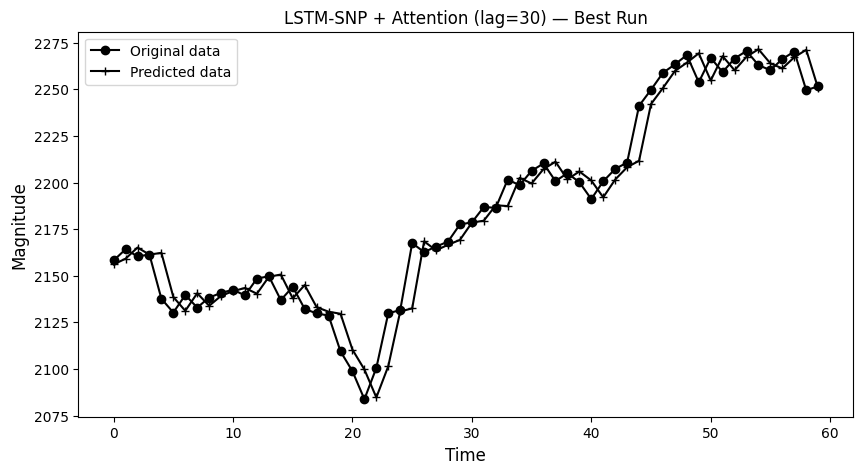

In [42]:
# ============================================================
# Attention (lag=30) Summary Statistics
# ============================================================

print('\n===== LSTM-SNP + Attention (lag=30) FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(att30_all_rmse):.10f} ± {np.var(att30_all_rmse):.15f}')
print(f'MSE:  {np.mean(att30_all_mse):.10f} ± {np.var(att30_all_mse):.15f}')
print(f'NMSE: {np.mean(att30_all_nmse):.10f} ± {np.var(att30_all_nmse):.15f}')

best_att30_idx = att30_all_rmse.index(min(att30_all_rmse))
print(f'\nBest run: {best_att30_idx+1}')
print(f'  RMSE: {att30_all_rmse[best_att30_idx]:.15f}')
print(f'  MSE:  {att30_all_mse[best_att30_idx]:.15f}')
print(f'  NMSE: {att30_all_nmse[best_att30_idx]:.15f}')

# Plot best run
actual = raw_values[-60:]
best_att30_preds = att30_all_predictions[best_att30_idx]

plt.figure(figsize=(10, 5))
plt.plot(actual, 'k-o', label='Original data')
plt.plot(best_att30_preds, 'k+-', label='Predicted data')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend()
plt.title('LSTM-SNP + Attention (lag=30) — Best Run')
plt.show()


In [43]:
# ============================================================
# FINAL COMPREHENSIVE SUMMARY — ALL MODELS
# Average ± Std Dev over 30 runs for RMSE, MSE, NMSE
# ============================================================

models = {
    'LSTM-SNP (Baseline, lag=1)': (all_rmse, all_mse, all_nmse),
    'BiLSTM-SNP (lag=1)': (bi_all_rmse, bi_all_mse, bi_all_nmse),
    'Attention (lag=1, degenerate)': (att1_all_rmse, att1_all_mse, att1_all_nmse),
    'Attention (lag=5)': (att5_all_rmse, att5_all_mse, att5_all_nmse),
    'Attention (lag=10)': (att10_all_rmse, att10_all_mse, att10_all_nmse),
    'Attention (lag=20)': (att20_all_rmse, att20_all_mse, att20_all_nmse),
    'Attention (lag=30)': (att30_all_rmse, att30_all_mse, att30_all_nmse),
}

print('=' * 110)
print('COMPREHENSIVE RESULTS — All Models (30 runs each)')
print('=' * 110)
print(f"{'Model':<35} {'Avg RMSE':>12} {'± Std':>12} {'Avg MSE':>14} {'± Std':>14} {'Avg NMSE':>16} {'± Std':>16}")
print('-' * 110)

for name, (rmse_list, mse_list, nmse_list) in models.items():
    print(
        f"{name:<35} "
        f"{np.mean(rmse_list):>12.6f} {np.std(rmse_list):>12.6f} "
        f"{np.mean(mse_list):>14.6f} {np.std(mse_list):>14.6f} "
        f"{np.mean(nmse_list):>16.10f} {np.std(nmse_list):>16.10f}"
    )

print('=' * 110)


COMPREHENSIVE RESULTS — All Models (30 runs each)
Model                                   Avg RMSE        ± Std        Avg MSE          ± Std         Avg NMSE            ± Std
--------------------------------------------------------------------------------------------------------------
LSTM-SNP (Baseline, lag=1)             11.142163     0.024938     124.148418       0.556623     0.0007537286     0.0000043813
BiLSTM-SNP (lag=1)                     11.199501     0.025030     125.429439       0.560757     0.0007616362     0.0000038514
Attention (lag=1, degenerate)          11.136433     0.023682     124.020709       0.527916     0.0007527141     0.0000043251
Attention (lag=5)                      11.146256     0.171817     124.268539       3.961709     0.0007576448     0.0000216609
Attention (lag=10)                     11.172695     0.100420     124.839204       2.229924     0.0007635582     0.0000217267
Attention (lag=20)                     11.262123     0.143274     126.855934       

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
print(f"Modified time (s * 0.5 * 0.25): {_NOTEBOOK_ELAPSED * 0.5 * 0.25:.2f} mins")
print(f"Process ID: {os.getpid()}")
